In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,confusion_matrix,classification_report)

In [4]:
DATA_PATH = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Churn Label"

y = df[TARGET].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(columns=[TARGET]).copy()



In [5]:
columns_to_drop = [
    "Count",
    "Country",
    "State",
    "CustomerID",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

X = X.drop(columns=columns_to_drop)

X["Total Charges"] = pd.to_numeric(
    X["Total Charges"],
    errors="coerce"
)

X.loc[
    (X["Tenure Months"] == 0) &
    (X["Total Charges"].isna()),
    "Total Charges"
] = 0

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 25)
y shape: (7043,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (5634, 25)
X_test : (1409, 25)


In [7]:
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))

Numerical: 7
Categorical: 18


In [8]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [9]:
def create_preprocessor():

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numerical_pipeline,
                numerical_features
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
results = []
trained_pipelines = {}

preprocessor = create_preprocessor()

for name, model in models.items():


    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    trained_pipelines[name] = pipeline

    print(f"{name} completed.")


Training Logistic Regression...


Logistic Regression completed.
Training Decision Tree...
Decision Tree completed.
Training Random Forest...
Random Forest completed.


In [12]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.787083,0.614198,0.532086,0.570201,0.833698,0.624426
1,Decision Tree,0.757984,0.547826,0.505348,0.525730,0.677311,0.408141
2,Random Forest,0.796309,0.660517,0.478610,0.555039,0.842335,0.645638


In [13]:
for name, pipeline in trained_pipelines.items():

    predictions = pipeline.predict(X_test)

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "No Churn",
                "Churn"
            ]
        )
    )



Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Decision Tree
              precision    recall  f1-score   support

    No Churn       0.83      0.85      0.84      1035
       Churn       0.55      0.51      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.75      1409



Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.66      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0

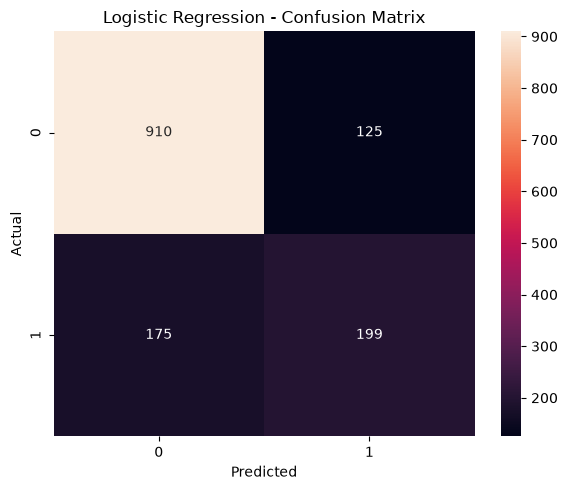

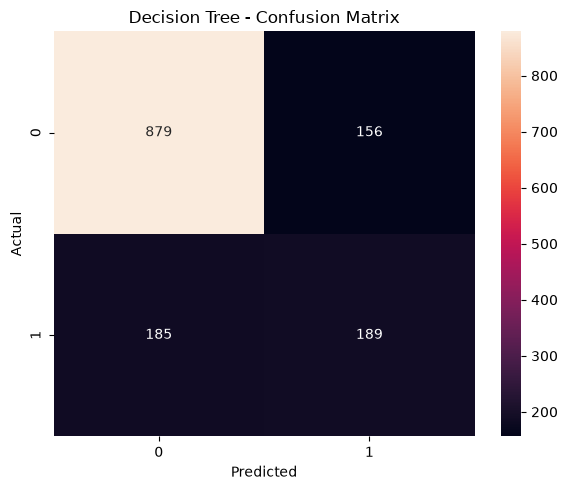

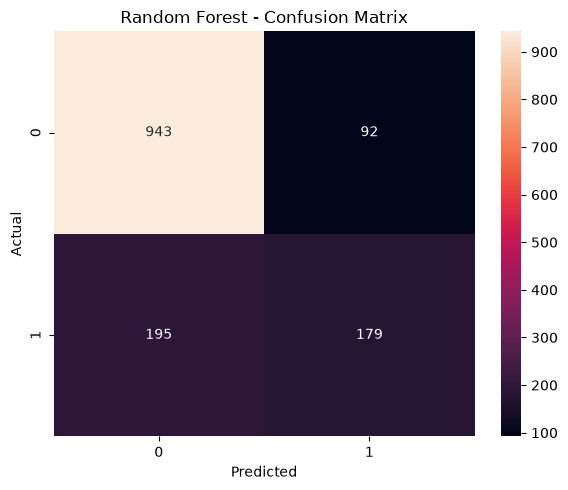

In [14]:
for name, pipeline in trained_pipelines.items():

    predictions = pipeline.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

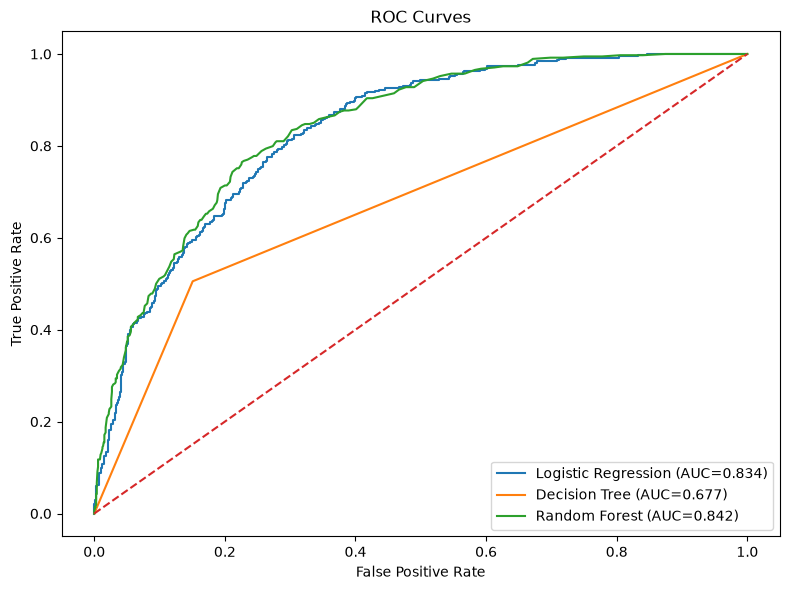

In [15]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, pipeline in trained_pipelines.items():

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
results_df.to_csv(
    "../data/processed/customer_churn_baseline_results.csv",
    index=False
)

print("Baseline evaluation results saved.")

Baseline evaluation results saved.
